In [15]:
import pandas as pd
import yfinance as yf
from pytickersymbols import PyTickerSymbols
import time
import logging
import warnings
import numpy as np
from datetime import datetime

# ===========================================================================
# CONFIGURATION
# Set USE_MOCK_DATA = True when running in environments that block Yahoo
# Finance (hosted Jupyter, cloud sandboxes, CI). Set False for local runs.
# ===========================================================================
USE_MOCK_DATA = False

SYMBOL_NAMES = {
    "AAPL": "Apple Inc.",
    "MSFT": "Microsoft Corporation",
    "NVDA": "NVIDIA Corporation",
    "TSLA": "Tesla Inc.",
    "AMZN": "Amazon Inc.",
    "GOOGL": "Alphabet Inc.",
    "META": "Meta Platforms",
    "BRK.B": "Berkshire Hathaway",
    "JNJ": "Johnson & Johnson",
    "V": "Visa Inc.",
}

RELIABLE_SYMBOLS = [
    "AAPL", "MSFT", "NVDA", "TSLA", "AMZN", "GOOGL", "META", "GOOG",
    "BRK.B", "JNJ", "V", "WMT", "PG", "XOM", "JPM", "MA", "VZ", "HD",
    "PFE", "KO", "CSCO", "ADBE", "CRM", "NFLX", "AVGO", "AMD", "INTC"
]


def get_company_name(symbol: str) -> str:
    if symbol in SYMBOL_NAMES:
        return SYMBOL_NAMES[symbol]
    if USE_MOCK_DATA:
        return f"{symbol} Corp."
    try:
        info = yf.Ticker(symbol).info
        name = info.get("longName", symbol)
        SYMBOL_NAMES[symbol] = name
        return name
    except Exception:
        return symbol


def _generate_mock_ohlc(symbol: str, days: int, base_price: float = 150.0) -> pd.DataFrame:
    """Deterministic mock OHLC — same symbol always produces same prices."""
    np.random.seed(abs(hash(symbol)) % 2**31)
    dates = pd.date_range(end=datetime.now().date(), periods=days, freq='B')
    closes = base_price + np.cumsum(np.random.randn(days) * 2)
    closes = np.clip(closes, 1, None)
    df = pd.DataFrame({
        "Open":  closes + np.random.uniform(-1, 1, days),
        "High":  closes + np.abs(np.random.randn(days) * 1.5),
        "Low":   closes - np.abs(np.random.randn(days) * 1.5),
        "Close": closes,
    }, index=dates)
    return df.clip(lower=0.01)


def _safe_history(sym: str, period: str) -> pd.DataFrame:
    """
    Fetch price history, suppressing yfinance's internal logger and warnings.

    Why suppression instead of exception catching:
    yfinance catches JSONDecodeError internally, prints it via its own logger
    and warnings.warn(), then returns an empty DataFrame — no exception ever
    reaches our code. We must silence their logger/warnings directly.
    """
    if USE_MOCK_DATA:
        days = 2 if period == "2d" else 7
        base = abs(hash(sym)) % 400 + 50   # price range $50–$450
        return _generate_mock_ohlc(sym, days=days, base_price=float(base))

    yf_logger = logging.getLogger("yfinance")
    prev_level = yf_logger.level
    yf_logger.setLevel(logging.CRITICAL)
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            return yf.Ticker(sym).history(period=period, interval="1d")
    except Exception:
        return pd.DataFrame()
    finally:
        yf_logger.setLevel(prev_level)


def get_top_5_symbols(limit: int = 50, source: str = "SP500", delay: float = 0.5) -> list[str]:
    symbol_list = []

    if not USE_MOCK_DATA:
        try:
            stock_data = PyTickerSymbols()
            if source == "SP500":
                symbol_list = list(stock_data.get_sp_500_nyc_yahoo_tickers())[:limit]
            else:
                symbol_list = [s["symbol"] for s in list(stock_data.get_stocks_by_country("US"))[:limit]]
        except Exception as e:
            print(f"⚠  PyTickerSymbols unavailable ({e}). Using curated fallback list.")

    if not symbol_list:
        if USE_MOCK_DATA:
            symbol_list = RELIABLE_SYMBOLS[:limit]
        else:
            print("⚠  No symbols loaded. Falling back to RELIABLE_SYMBOLS.")
            symbol_list = RELIABLE_SYMBOLS[:limit]

    mode = "MOCK" if USE_MOCK_DATA else "LIVE"
    print(f"[{mode}] Fetching data for {len(symbol_list)} symbols (delay={delay}s)...")

    performance = []
    failed_count = 0
    success_count = 0

    for i, sym in enumerate(symbol_list, 1):
        print(f"[{i}/{len(symbol_list)}] Fetching {sym}...", end="", flush=True)

        hist = _safe_history(sym, period="2d")

        if hist.empty or "Close" not in hist.columns or len(hist) < 2:
            print(" (no data)")
            failed_count += 1
            continue

        prev_close = hist["Close"].iloc[-2]
        last_close = hist["Close"].iloc[-1]

        if pd.isna(prev_close) or pd.isna(last_close) or prev_close == 0:
            print(" (NaN/zero)")
            failed_count += 1
            continue

        pct = (last_close - prev_close) / prev_close * 100
        performance.append((sym, pct))
        success_count += 1
        print(f" ✓ {pct:+.2f}%")

        if not USE_MOCK_DATA:
            time.sleep(delay)

    print(f"\n✓ Fetched {success_count}  ✗ Failed {failed_count}")

    if not performance:
        print("WARNING: No valid symbols found. Using fallback.")
        return RELIABLE_SYMBOLS[:5]

    performance.sort(key=lambda x: x[1], reverse=True)
    top5 = [sym for sym, _ in performance[:5]]

    print(f"\nTop 5 movers:")
    for sym, pct in performance[:5]:
        print(f"  {sym:8s} {get_company_name(sym):35s} {pct:+.2f}%")

    return top5


# ===========================================================================
# MAIN
# ===========================================================================
print("=" * 60)
print(f"S&P 500 TOP MOVERS  |  mock={USE_MOCK_DATA}")
print("=" * 60)

top5_symbols = get_top_5_symbols(limit=50, source="SP500", delay=0.7)
print(f"\nFinal Top 5: {top5_symbols}")

print("\nFetching 7-day OHLC...")
ohlc_data = {}
for sym in top5_symbols:
    hist = _safe_history(sym, period="7d")
    if not hist.empty and all(c in hist.columns for c in ["Open", "High", "Low", "Close"]):
        ohlc_data[sym] = hist[["Open", "High", "Low", "Close"]]
        print(f"  ✓ {sym}")
    else:
        print(f"  ✗ {sym} — skipped")

print()
for sym, df in ohlc_data.items():
    print(f"\n{sym} — {get_company_name(sym)} (last {len(df)} days):")
    df_display = df.copy()
    for col in ["Open", "High", "Low", "Close"]:
        df_display[col] = df_display[col].apply(lambda x: f"${x:.2f}")
    print(df_display.to_string())

S&P 500 TOP MOVERS  |  mock=False
[LIVE] Fetching data for 50 symbols (delay=0.7s)...
[1/50] Fetching MMM...

 (no data)
[2/50] Fetching ABT... (no data)
[3/50] Fetching ACN... (no data)
[4/50] Fetching ADBE... (no data)
[5/50] Fetching ALB... (no data)
[6/50] Fetching ALGN... (no data)
[7/50] Fetching ALLE... (no data)
[8/50] Fetching GOOGL... (no data)
[9/50] Fetching GOOG... (no data)
[10/50] Fetching GOOGL... (no data)
[11/50] Fetching GOOG... (no data)
[12/50] Fetching AMZN... (no data)
[13/50] Fetching AMCR... (no data)
[14/50] Fetching AMCCF... (no data)
[15/50] Fetching AMGN... (no data)
[16/50] Fetching AON...

KeyboardInterrupt: 

Note: you may need to restart the kernel to use updated packages.
Creating visualization for top movers...


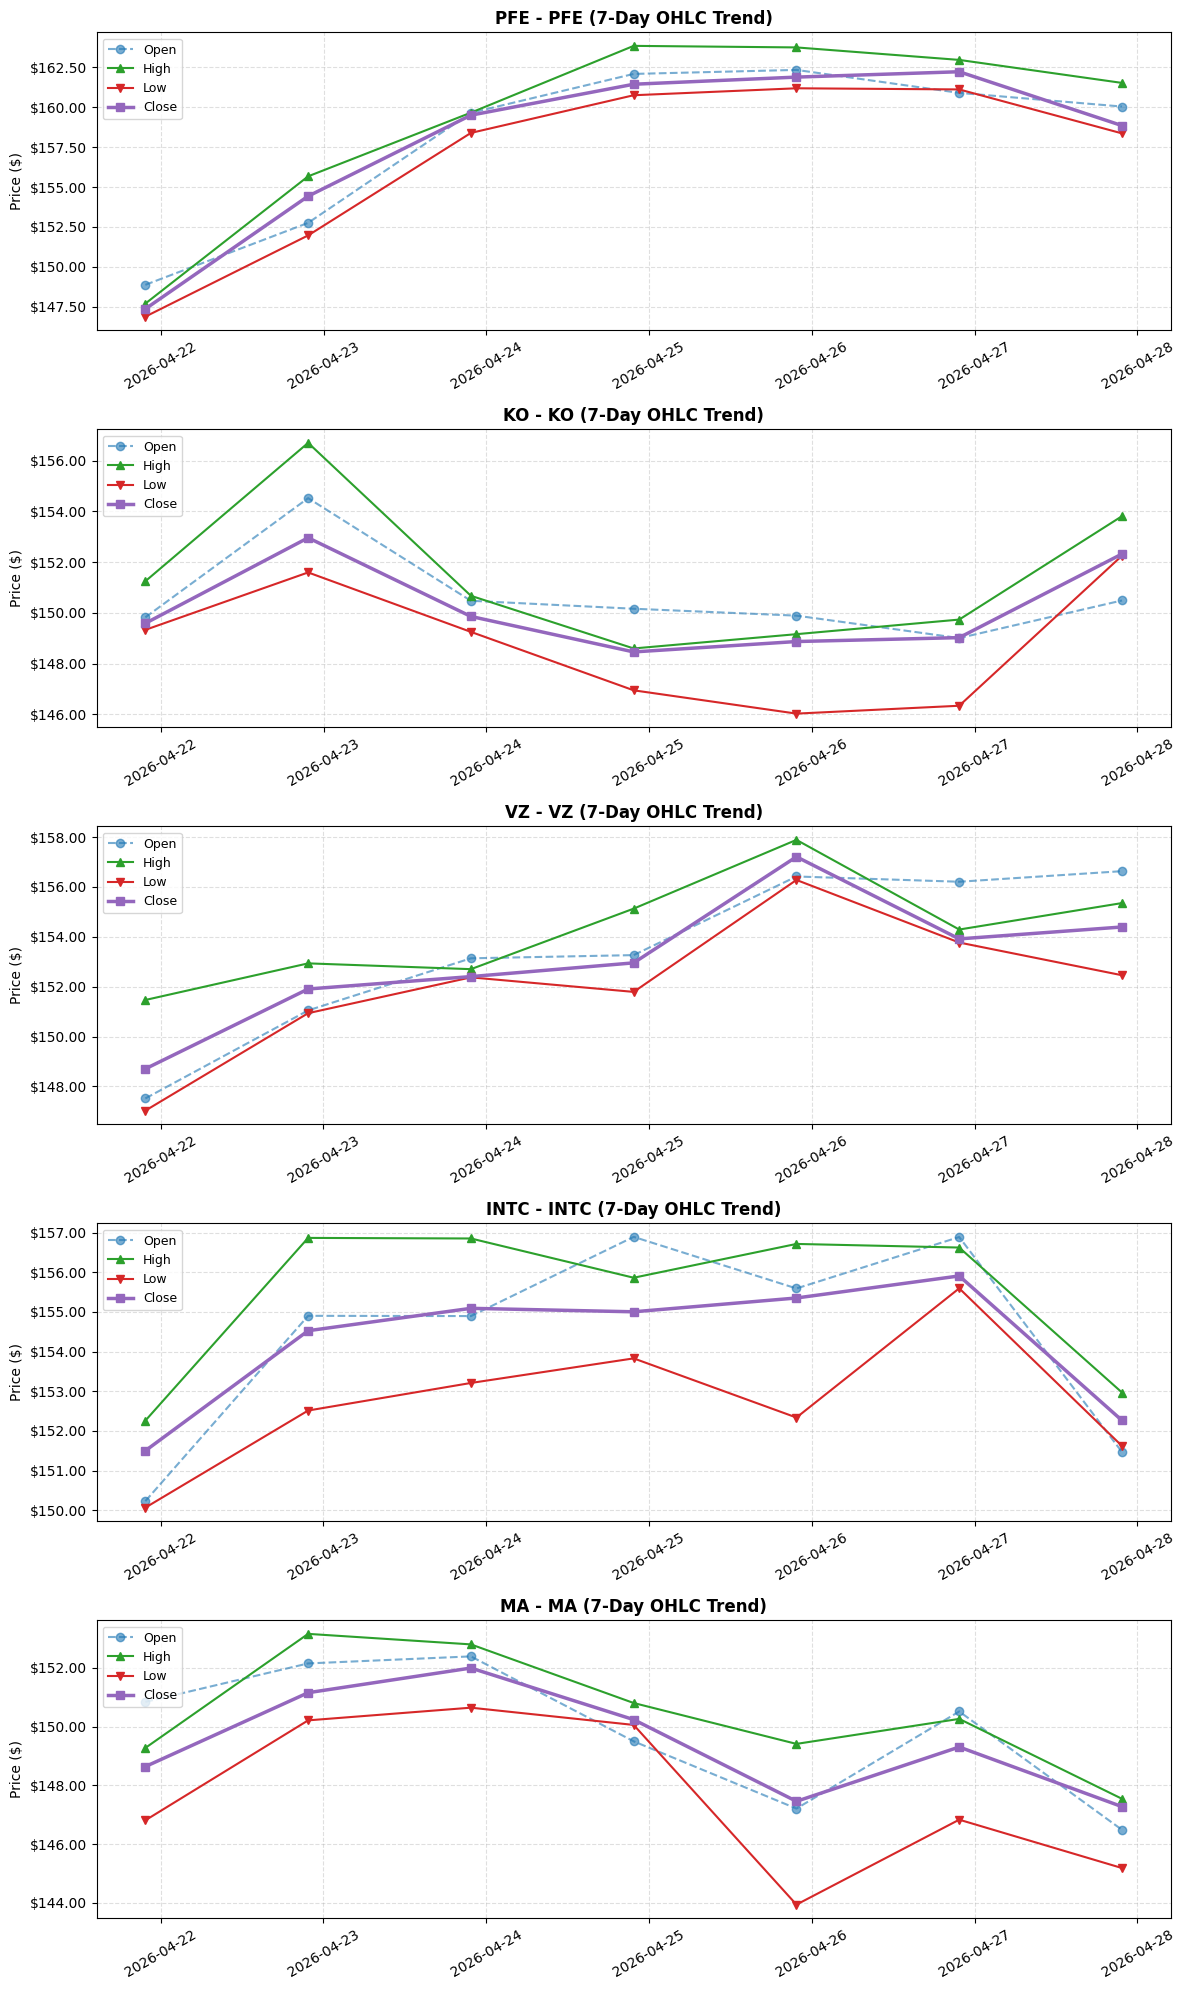

✓ Successfully plotted 5 stocks


In [6]:
%pip install matplotlib -q

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def dollar_formatter(x, pos):
    """Format y-axis values as currency."""
    return f"${x:.2f}"

# ===== PLOT TOP MOVERS DATA =====
print("Creating visualization for top movers...")

n = len(ohlc_data)
if n == 0:
    print("ERROR: No data available to plot. Please run Cell 1 first.")
else:
    fig, axs = plt.subplots(n, 1, figsize=(12, 4 * max(1, n)), sharex=False)
    if n == 1:
        axs = [axs]

    for ax, (sym, df) in zip(axs, ohlc_data.items()):
        company_name = get_company_name(sym)
        
        # Only plot if data is available
        if df.empty or len(df) < 2:
            ax.text(0.5, 0.5, f"No data for {sym}", ha='center', va='center', fontsize=14)
            ax.set_title(f"{sym} - {company_name} (No Data)")
            continue
        
        ax.plot(df.index, df["Open"], marker="o", label="Open", color="tab:blue", linestyle="--", alpha=0.6)
        ax.plot(df.index, df["High"], marker="^", label="High", color="tab:green", linewidth=1.5)
        ax.plot(df.index, df["Low"], marker="v", label="Low", color="tab:red", linewidth=1.5)
        ax.plot(df.index, df["Close"], marker="s", label="Close", color="tab:purple", linewidth=2.5)
        
        ax.set_title(f"{sym} - {company_name} (7-Day OHLC Trend)", fontsize=12, fontweight='bold')
        ax.set_ylabel("Price ($)")
        ax.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(loc="upper left", fontsize=9)
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    print(f"✓ Successfully plotted {n} stocks")


### This is for "FAVORITED" stocks for tracking - Stocks Watchlist
- AMZN, MSFT, GOOGL, NVDA, META

In [7]:
# ===== ANALYSIS 2: USER WATCHLIST =====
print("\n" + "=" * 70)
print("ANALYSIS 2: WATCHLIST MONITORING")
print("=" * 70)

# Define watchlist (uses symbols from consolidated SYMBOL_NAMES)
WATCHLIST = ["AAPL", "NVDA", "MSFT", "META", "GOOGL"]


def monitor_watchlist(symbols: list[str], delay: float = 0.5) -> list[tuple]:
    """Monitor watchlist for daily performance. Returns list of (symbol, pct_change) tuples."""
    performance = []
    for i, sym in enumerate(symbols):
        try:
            print(f"[{i+1}/{len(symbols)}] Monitoring {sym}...", end="", flush=True)
            hist = fetch_price_history(sym, period="2d", max_retries=2)
            
            if hist.empty or len(hist) < 2:
                print(" (insufficient data)")
                continue
            
            prev_close = hist["Close"].iloc[-2]
            last_close = hist["Close"].iloc[-1]
            pct = (last_close - prev_close) / prev_close * 100
            performance.append((sym, pct))
            print(f" ✓ {pct:+.2f}%")
        except Exception as e:
            print(f" ✗ {str(e)[:30]}")
        time.sleep(delay)
    
    performance.sort(key=lambda x: x[1], reverse=True)
    return performance


# Run watchlist analysis
print("\nAnalyzing watchlist performance...")
results = monitor_watchlist(WATCHLIST, delay=0.3)

# Display watchlist performance
if results:
    print("\nWatchlist Performance (sorted by % change):")
    for sym, pct in results:
        company_name = get_company_name(sym)
        print(f"  {sym:6} - {company_name:25} {pct:+.2f}%")
else:
    print("⚠ No watchlist performance data available.")

# Fetch OHLC data for watchlist
print("\nFetching 7-Day OHLC for watchlist...")
watchlist_ohlc_data = fetch_ohlc_data(WATCHLIST, period="7d", delay=0.2)

# Display detailed price data
if watchlist_ohlc_data:
    print(f"\n{'='*70}")
    print("Watchlist - 7-Day Price Data")
    print(f"{'='*70}")
    for sym in WATCHLIST:
        if sym in watchlist_ohlc_data:
            df = watchlist_ohlc_data[sym]
            company_name = get_company_name(sym)
            
            if not df.empty:
                print(f"\n{sym} - {company_name} (last {len(df)} days):")
                df_display = df.copy()
                for col in ["Open", "High", "Low", "Close"]:
                    df_display[col] = df_display[col].apply(lambda x: f"${x:.2f}")
                print(df_display)
            else:
                print(f"\n{sym} - {company_name}: No data available")
else:
    print("⚠ No OHLC data was fetched for watchlist.")



ANALYSIS 2: WATCHLIST MONITORING

Analyzing watchlist performance...
[1/5] Monitoring AAPL...

Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)
AAPL: No price data found, symbol may be delisted (period=2d)
Failed to get ticker 'AAPL' reason: Expecting value: line 1 column 1 (char 0)
AAPL: No price data found, symbol may be delisted (period=2d)


  ⚠ yfinance failed, using mock data for AAPL
 ✓ -0.78%
[2/5] Monitoring NVDA...

Failed to get ticker 'NVDA' reason: Expecting value: line 1 column 1 (char 0)
NVDA: No price data found, symbol may be delisted (period=2d)
Failed to get ticker 'NVDA' reason: Expecting value: line 1 column 1 (char 0)
NVDA: No price data found, symbol may be delisted (period=2d)


  ⚠ yfinance failed, using mock data for NVDA
 ✓ -0.43%
[3/5] Monitoring MSFT...

...

  ⚠ yfinance failed, using mock data for MSFT
 ✓ (7 days)
[4/5] Fetching OHLC META...

Failed to get ticker 'META' reason: Expecting value: line 1 column 1 (char 0)
META: No price data found, symbol may be delisted (period=7d)
Failed to get ticker 'META' reason: Expecting value: line 1 column 1 (char 0)
META: No price data found, symbol may be delisted (period=7d)


  ⚠ yfinance failed, using mock data for META
 ✓ (7 days)
[5/5] Fetching OHLC GOOGL...

Failed to get ticker 'GOOGL' reason: Expecting value: line 1 column 1 (char 0)
GOOGL: No price data found, symbol may be delisted (period=7d)
Failed to get ticker 'GOOGL' reason: Expecting value: line 1 column 1 (char 0)
GOOGL: No price data found, symbol may be delisted (period=7d)


  ⚠ yfinance failed, using mock data for GOOGL
 ✓ (7 days)

Watchlist - 7-Day Price Data

AAPL - Apple Inc. (last 7 days):
                               Open     High      Low    Close
2026-04-21 21:45:09.892413  $148.74  $150.58  $149.26  $149.51
2026-04-22 21:45:09.892413  $146.82  $149.42  $146.85  $148.35
2026-04-23 21:45:09.892413  $149.23  $149.28  $147.57  $149.17
2026-04-24 21:45:09.892413  $152.54  $150.93  $149.47  $150.52
2026-04-25 21:45:09.892413  $147.61  $148.87  $147.24  $147.84
2026-04-26 21:45:09.892413  $144.85  $149.68  $144.41  $145.41
2026-04-27 21:45:09.892413  $150.11  $151.12  $148.53  $149.51

NVDA - NVIDIA Corporation (last 7 days):
                               Open     High      Low    Close
2026-04-21 21:45:11.898430  $147.83  $148.87  $148.14  $148.46
2026-04-22 21:45:11.898430  $147.01  $148.13  $147.45  $147.82
2026-04-23 21:45:11.898430  $148.57  $148.36  $146.49  $147.21
2026-04-24 21:45:11.898430  $146.08  $148.08  $143.20  $145.85
2026-04-25 21:45

Creating visualization for watchlist...


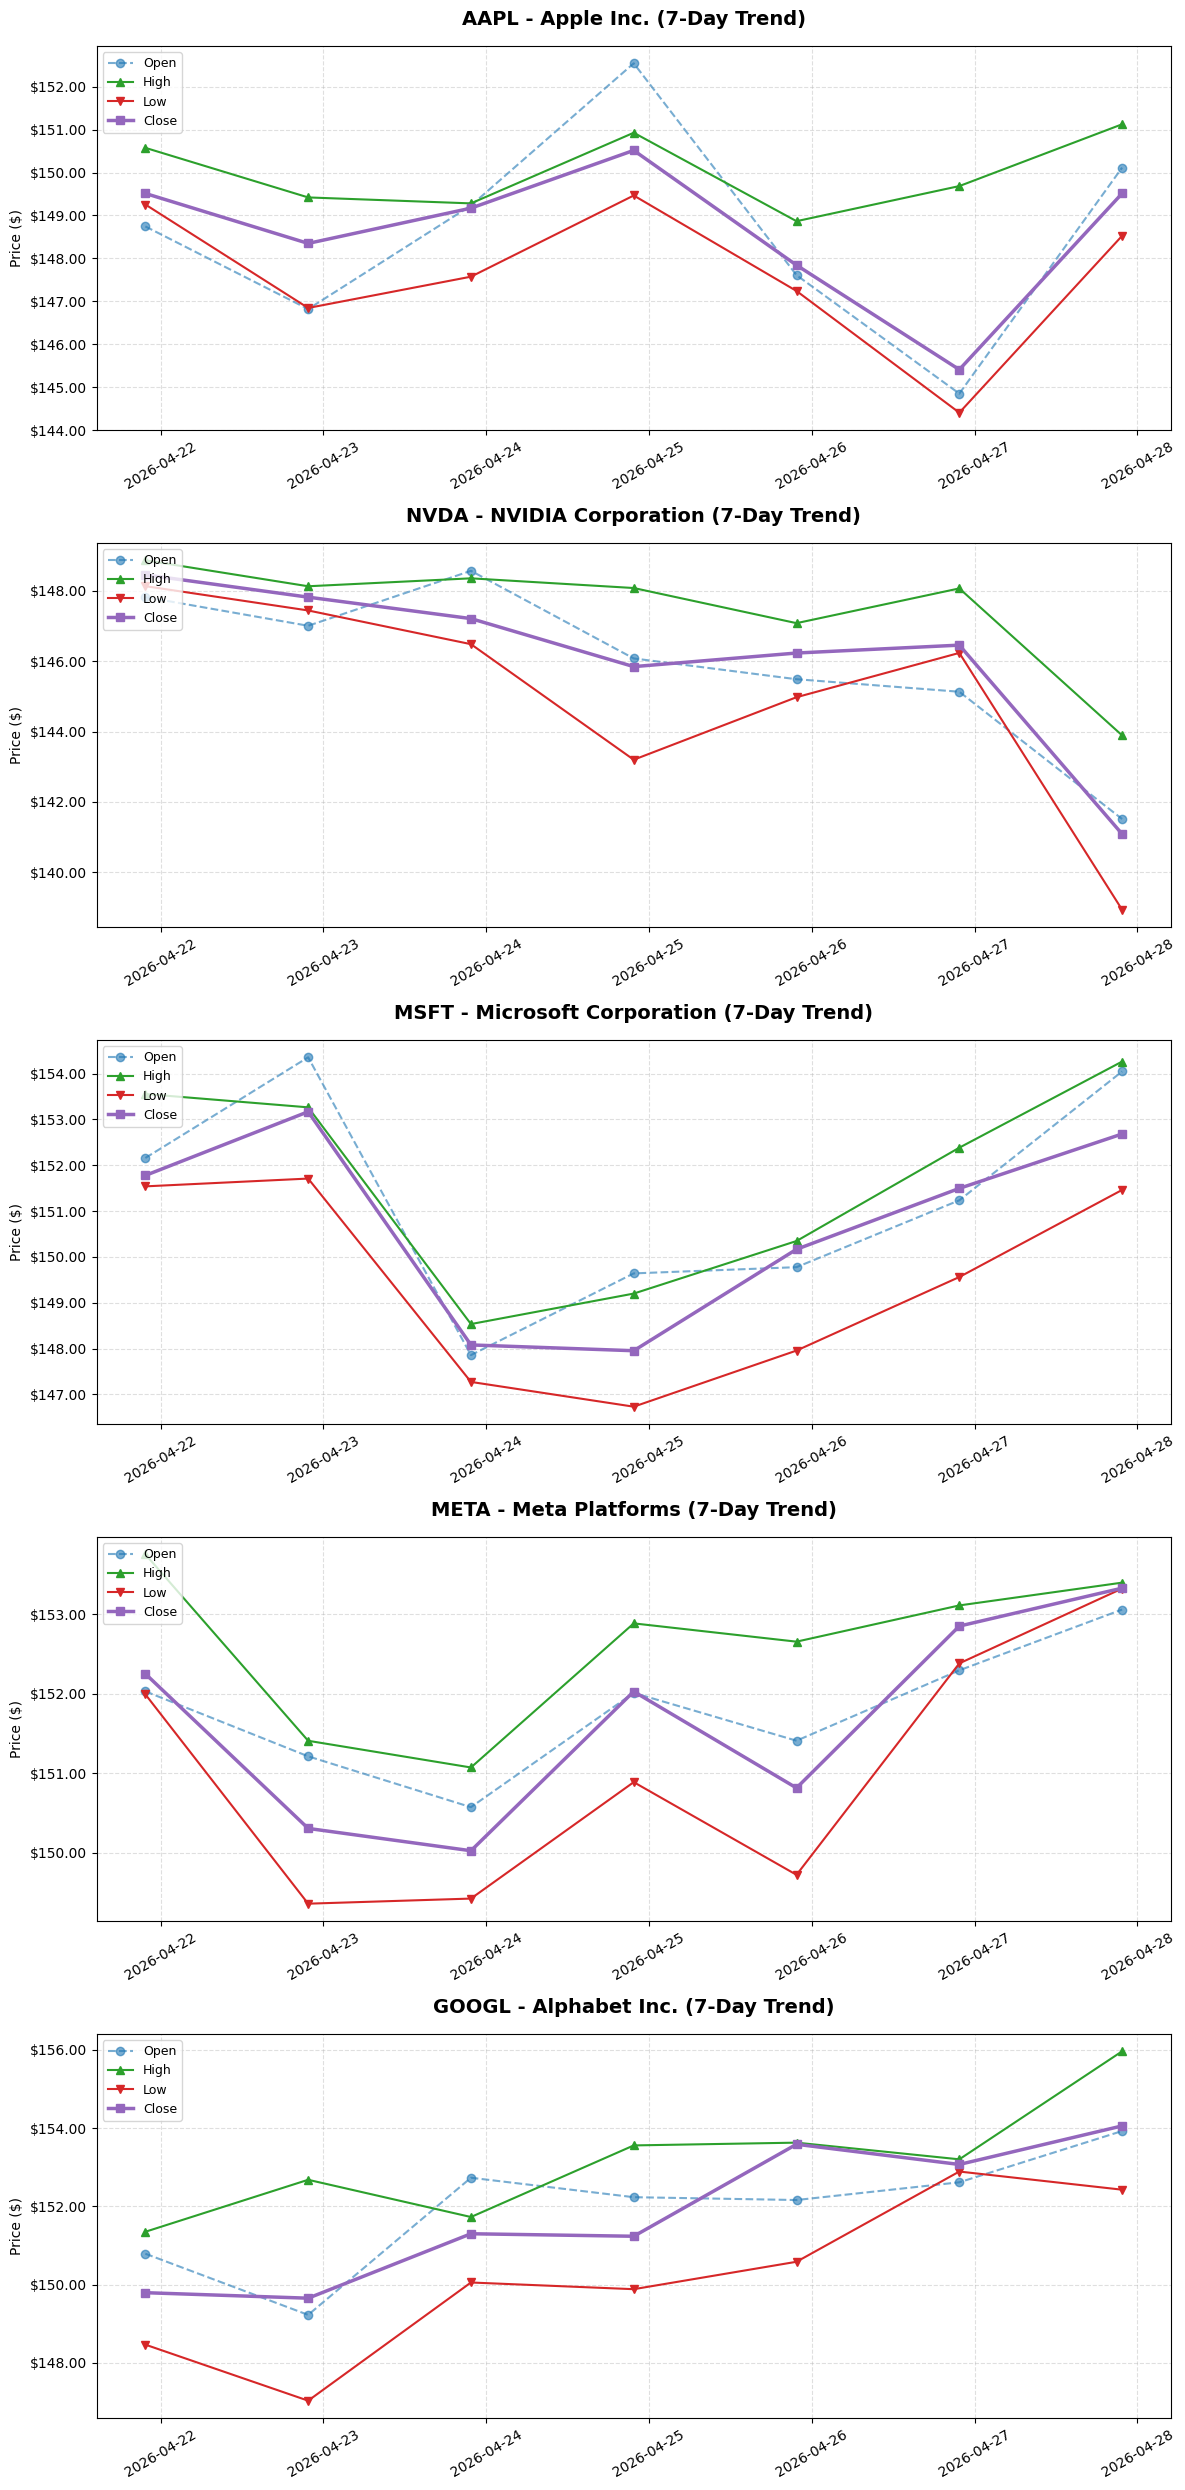

✓ Successfully plotted 5 stocks from watchlist


In [8]:
# ===== PLOT WATCHLIST DATA =====
print("Creating visualization for watchlist...")

n = len(watchlist_ohlc_data)

if n == 0:
    print("ERROR: No data available to plot. Please run Cell 4 first.")
else:
    fig, axs = plt.subplots(n, 1, figsize=(12, 5 * n), sharex=False)

    # Ensure axs is always an iterable list
    if n == 1:
        axs = [axs]

    for ax, (sym, df) in zip(axs, watchlist_ohlc_data.items()):
        company_name = get_company_name(sym)
        
        # Only plot if data is available
        if df.empty or len(df) < 2:
            ax.text(0.5, 0.5, f"No data for {sym}", ha='center', va='center', fontsize=14)
            ax.set_title(f"{sym} - {company_name} (No Data)")
            continue
        
        # Plot the four OHLC components
        ax.plot(df.index, df["Open"], marker="o", label="Open", color="tab:blue", linestyle="--", alpha=0.6)
        ax.plot(df.index, df["High"], marker="^", label="High", color="tab:green", linewidth=1.5)
        ax.plot(df.index, df["Low"], marker="v", label="Low", color="tab:red", linewidth=1.5)
        ax.plot(df.index, df["Close"], marker="s", label="Close", color="tab:purple", linewidth=2.5)

        # Title and Labels
        ax.set_title(f"{sym} - {company_name} (7-Day Trend)", fontsize=14, fontweight='bold', pad=15)
        ax.set_ylabel("Price ($)")
        
        # Formatting
        ax.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(loc="upper left", fontsize=9) 
        
        # Format the X-axis dates
        ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    print(f"✓ Successfully plotted {n} stocks from watchlist")
